# Attractive Hubbard BEC with pyALF

This notebook uses **pyALF** with the **Algorithm of Lattice Fermions (ALF)** to simulate the attractive Hubbard model and measure the on-site pair correlator directly.

$$N(\mathbf q)=\frac{1}{N}\sum_{i,j}e^{i\mathbf q\cdot(\mathbf r_i-\mathbf r_j)}\langle b_i^\dagger b_j\rangle,\qquad b_i^\dagger=c_{i\uparrow}^\dagger c_{i\downarrow}^\dagger.$$

The ALF source in this workspace has been extended with a native `Pair` observable. Its analyzed output is `Pair_eq_K`.

In [25]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from py_alf import ALF_source, Simulation
%matplotlib widget

alf_dir = ALF_source(alf_dir=str(Path.cwd() / 'ALF'))

## Compile ALF

This cell compiles the modified Hubbard executable once. It does not run a simulation yet.

In [31]:
compile_sim = Simulation(alf_src=alf_dir, ham_name='Hubbard',sim_dict={}) #sim_dict is used to choose parameters.
compile_sim.compile()

Compiling ALF... 
Cleaning up Prog/
Cleaning up Libraries/
Cleaning up Analysis/
Compiling Libraries


entanglement_mod.F90:35:2:

   35 | #warning "You are compiling entanglement without MPI. No Renyi entropy results possible, all other observables still work!"
      |  1~~~~~~
ar: creating archive modules_90.a
ar: creating archive libqrref.a


Compiling Analysis
Compiling Program
Compiling program modules
Parsing Hamiltonian parameters
filenames: Hamiltonians/Hamiltonian_Kondo_smod.F90 Hamiltonians/Hamiltonian_Kondo_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_smod.F90 Hamiltonians/Hamiltonian_Hubbard_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_smod.F90 Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_tV_smod.F90 Hamiltonians/Hamiltonian_tV_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_LRC_smod.F90 Hamiltonians/Hamiltonian_LRC_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Z2_Matter_smod.F90 Hamiltonians/Hamiltonian_Z2_Matter_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Spin_Peierls_smod.F90 Hamiltonians/Hamiltonian_Spin_Peierls_read_write_parameters.F90
Link program
Done.


## Run the simulations

The following cell runs each inverse temperature directly from this notebook. `N_SUN=2` is ALF's input convention for the two-flavor model; ALF reduces it internally to one color for the pair estimator.

In [33]:
LAT_SIZES = [4,6,8]
BETAS = [i for i in range(1,8)]

for beta in BETAS:
    for L in LAT_SIZES:
        sim = Simulation(
                    alf_dir, 'Hubbard',
                    {
                        ### Choice of Predefined Model###
                        'Model': 'Hubbard',
                        
                        ###Definition of the Lattice###
                        'Lattice_type': 'Square',
                        'L1': L,
                        'L2': L,
                        
                        #--- Model parameters ---#
                        'Beta': float(beta),
                        'ham_chem': 0.5,
                        'ham_U': -4.0,
                        #--- Simulation parameters --- #
                        'Nsweep': 10,
                        'NBin': 10,
                        'Mz': True, #Choice of HS-Transformation (Exclusive for Hubbard-type interactions); ALF-DOC: 8.3.2 M_Z-Hubbard interaction
                        'Checkerboard': True, #ALF-DOC: 2.3. The Trotter error and checkerboard decomposition
                        'Symm': True, #Symmetric Trotter decomposition; ALF-DOC: 2.3. The Trotter error and checkerboard decomposition

                        ###ALF Internal Flags###
                        'N_SUN': 2, #
                        'N_FL': 2, # 
                        'Ltau': 0, #Speed things up by not calculating time-displaced observables.
                    },
                    machine='GNU',
                    sim_dir=f'Attractive_Hubbard_L{L}_beta_{beta}'
                )
        sim.run()
        sim.analysis()
print('All simulations and analyses complete.')

Prepare directory "/Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF_data/Attractive_Hubbard_L4_beta_1" for Monte Carlo run.
Resuming previous run.
Run /Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
### Analyzing /Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF_data/Attractive_Hubbard_L4_beta_1 ###
/Users/luis/Documents/_WORK/HELKE_TUTORIAL
Scalar observables:
Ener_scal
Kin_scal
Part_scal
Pot_scal
Histogram observables:
Equal time observables:
Den_eq
Green_eq
Pair_eq
SpinT_eq
SpinXY_eq
SpinZ_eq
Time displaced observables:
Prepare directory "/Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF_data/Attractive_Hubbard_L6_beta_1" for Monte Carlo run.
Resuming previous run.
Run /Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 202

## Load $N(\mathbf q)$

`Pair_eq_K` is written by ALF's Fourier transform of the native `Pair` real-space correlator. The loader uses columns 0, 1, and 2: $q_x$, $q_y$, and the real pair structure factor.

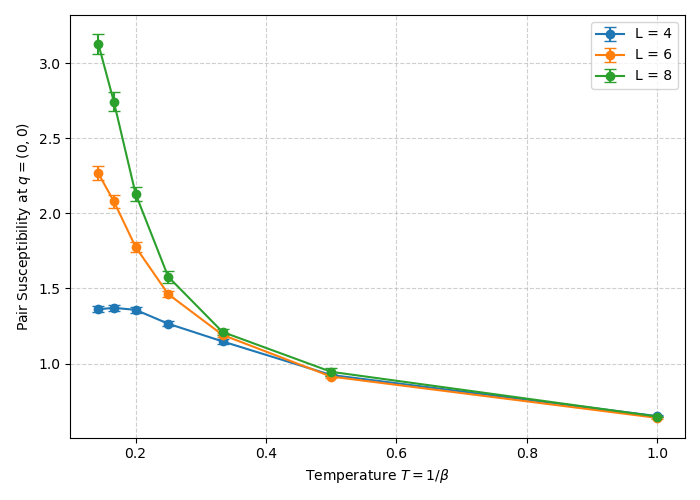

In [ ]:
#TODO: This needs to be done the "pyALF" way/utilize pyALF functions.



import glob
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

# Group points: data_by_L[L] = list of (T, value, error)
data_by_L = defaultdict(list)

for path in glob.glob("ALF_data/*/res/Pair_eq_K"):
    match = re.search(r"_L(\d+)_beta_([0-9.]+)", path)
    if not match:
        continue

    L = int(match.group(1))
    beta = float(match.group(2))
    T = 1.0 / beta

    # Load data: col 0 = kx, col 1 = ky, col 2 = value, col 3 = error
    data = np.loadtxt(path)

    # Select q = (0, 0)
    zero_q_row = data[(np.isclose(data[:, 0], 0.0)) & (np.isclose(data[:, 1], 0.0))]

    if len(zero_q_row) > 0:
        val = zero_q_row[0, 2]
        err = zero_q_row[0, 3]
        data_by_L[L].append((T, val, err))

# Plot
plt.figure(figsize=(7, 5))

for L in sorted(data_by_L.keys()):
    pts = sorted(data_by_L[L], key=lambda x: x[0])
    T_vals = [p[0] for p in pts]
    vals = [p[1] for p in pts]
    errs = [p[2] for p in pts]

    # x-axis: T, y-axis: value + error
    plt.errorbar(
        T_vals,
        vals,
        yerr=errs,
        fmt="o-",
        capsize=4,
        label=f"L = {L}",
    )

plt.xlabel(r"Temperature $T = 1/\beta$")
plt.ylabel(r"Pair Susceptibility at $q=(0,0)$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

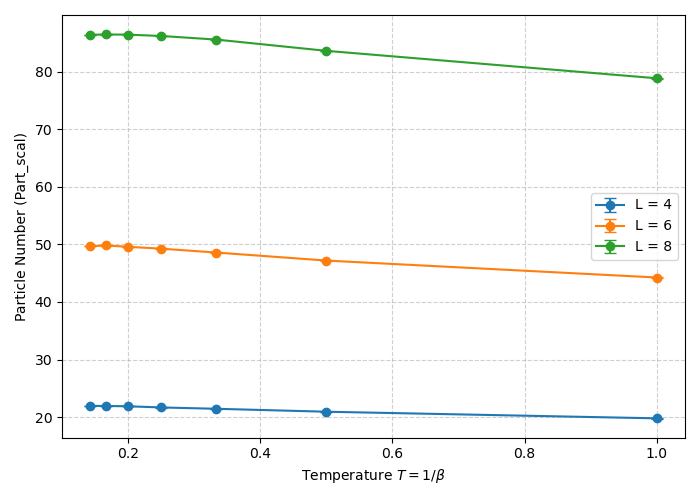

In [37]:
import glob
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

# Group data by lattice size: data_by_L[L] = list of (T, value, error)
data_by_L = defaultdict(list)

# Find all Part_scal files inside ALF_data
file_paths = glob.glob("ALF_data/*/res/Part_scal")

for path in file_paths:
    # Extract L and beta from directory name (e.g. Attractive_Hubbard_L4_beta_1)
    match = re.search(r"_L(\d+)_beta_([0-9.]+)", path)
    if not match:
        continue

    L = int(match.group(1))
    beta = float(match.group(2))
    T = 1.0 / beta

    # Load data: col 0 = value, col 1 = error (lines starting with # are skipped)
    data = np.loadtxt(path)

    # Flatten if 1D array
    val = data[0] if data.ndim > 0 else float(data)
    err = data[1] if data.ndim > 0 and len(data) > 1 else 0.0

    data_by_L[L].append((T, val, err))

# Plot
plt.figure(figsize=(7, 5))

for L in sorted(data_by_L.keys()):
    # Sort points by T for clean line connecting
    pts = sorted(data_by_L[L], key=lambda x: x[0])
    T_vals = [p[0] for p in pts]
    vals = [p[1] for p in pts]
    errs = [p[2] for p in pts]

    plt.errorbar(
        T_vals,
        vals,
        yerr=errs,
        fmt="o-",
        capsize=4,
        label=f"L = {L}",
    )

plt.xlabel(r"Temperature $T = 1/\beta$")
plt.ylabel("Particle Number (Part_scal)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()